In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    # b_std = 'b' + str(i) + '_std'
    # b_name.append(b_std)


# b_name = np.array(b_name)
# b_name

In [4]:
cols_rdmc = b_name + ["CWM_log10_LDMC", "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
cols_srl = b_name+ ["CWM_log10_SLA"]+ ["CWM_log10_LA"]+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rtd = b_name+ ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd = b_name+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


cols_sra = b_name + ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rbd = b_name+ ["CWM_log10_LA"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcc = b_name+ ["CWM_log10_PC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rd13c = b_name+ ["CWM_Ld13C"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rnc = b_name+ ["CWM_log10_PN"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd15n = b_name+ ["CWM_Ld15N"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcn = b_name+ ["CN_ratio"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [5]:
x_RDMC = np.array(df_svc_RDMC[cols_rdmc] )
x_SRL = np.array(df_svc_SRL[cols_srl])
x_RTD = np.array(df_svc_RTD[cols_rtd])
x_RD = np.array(df_svc_RD[cols_rd])
x_SRA = np.array(df_svc_SRA[cols_sra])
x_RBD = np.array(df_svc_RBD[cols_rbd])
x_RLD = np.array(df_svc_RLD[cols_rld])
x_RD13C = np.array(df_svc_RD13C[cols_rd13c])
x_RNC = np.array(df_svc_RNC[cols_rnc])
x_RD15N = np.array(df_svc_RD15N[cols_rd15n])
x_RCN = np.array(df_svc_RCN[cols_rcn])
x_RCC = np.array(df_svc_RCC[cols_rcc])

In [6]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [7]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [8]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [9]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [10]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [11]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  21
Wavelengths to be kept  53
Optimised MSEP  42.544864366019716



[229.94819845 167.26494783 319.53665922 288.21393076 291.46864969
 287.05036751 241.15937376 221.80610862 159.51958067 241.25377605
 252.47433729 256.23797432 274.69944472 259.83090747 355.72381249
 199.78350382 240.30527233 295.77828214 207.71085762 306.49003012
 327.647077   217.09668205 388.11036877 218.63420284 237.75968331
 297.9036248  372.57625961 335.37744151 370.70187488 249.8961219
 259.05125095 413.78317641 297.09788031 400.64435007 385.92632303
 311.70484397 344.37832608 274.62008222 277.90041284 343.162817
 361.46375778 330.16148352 303.59011729 323.37834133 328.72811738
 325.87265956 317.01423628 326.81673571 352.99920345 326.30587739
 303.60053074 323.10986504 342.65233815 308.32402651 351.17804479
 301.62849266 330.79868821 318.1707379  313.76059049 322.91325732
 331.8151694  312.97829898 297.17545516 327.2198003  322.90994005
 336.76142531 321.61813333 325.62987316 304.10855697 308.59901342
 276.69019802 349.82029078 320.21165365 312.26037286 325.48754271
 325.54858492

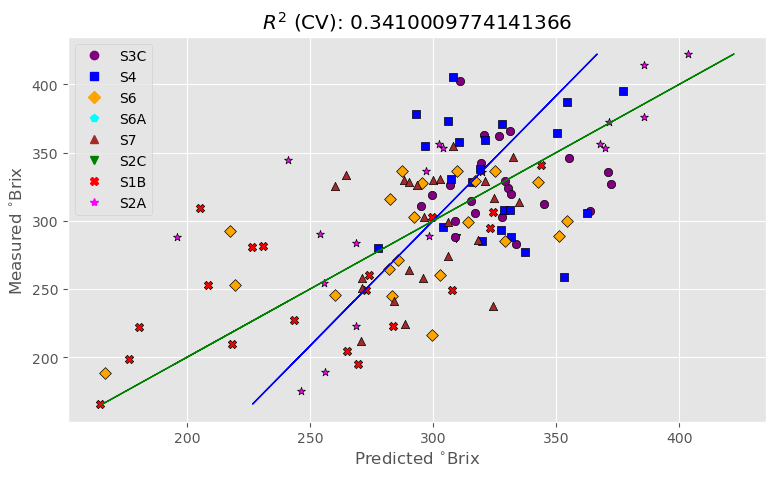

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [14]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  11
Wavelengths to be kept  24
Optimised MSEP  32.595190277496286



[105.74595168 114.19804871 113.82537104 143.26757979 129.24207629
 121.50883025 107.47488466 134.54858652 108.99383367  96.18561972
 116.12737474 117.22649017 137.17381609 121.91290302 108.27794874
 118.07831801 111.31962619 125.76958643 101.75477153  49.29696892
  35.08122431  78.90348094  70.10546071  47.70397735  47.16939773
  62.98647567  30.34779255  66.72213883  61.51154555  30.63681905
  24.27778523  64.60781769  42.36810629  71.55247759  22.13679
  24.04297914  68.37824044 119.26581219 137.72167078 102.31007763
 117.10171149 158.50040688 129.96829795 128.73862523 119.41640177
 139.52261817 153.62149614 149.80863236 135.08375504 122.98849973
 133.95436676 131.22431592 128.60185319 126.81672921 132.19337941
 123.55036115 139.59191527  91.85788498 130.30222917 143.0204843
 139.29479476 120.24193214 116.33797316 134.67292445 139.13147296
 139.26475464 123.95227287 126.76484117 127.06707245 138.28890059
 141.34113978 136.6777639  142.22852649 133.98665442 130.95868372
 141.40681245 

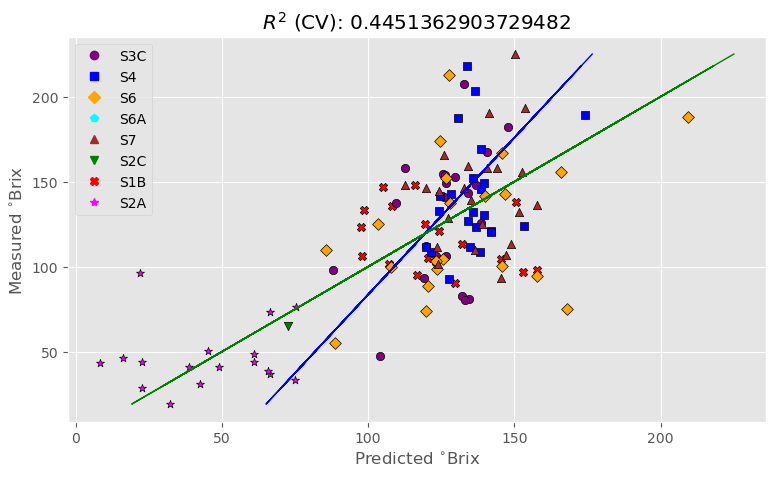

In [15]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

## RTD
 

In [16]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  24
Wavelengths to be kept  27
Optimised MSEP  0.0846604609928124



[0.3537554  0.26260199 0.27379046 0.47193615 0.43524539 0.49468511
 0.36263481 0.49174568 0.32999554 0.42768983 0.42529707 0.47603502
 0.53893542 0.45920995 0.55701054 0.42800127 0.4519756  0.43129559
 0.50513139 0.37568603 0.37348558 0.38710437 0.55578444 0.57069818
 0.48207355 0.4748658  0.55319775 0.46489052 0.5282977  0.49743666
 0.47391191 0.53926297 0.43957609 0.35288364 0.6276179  0.7346776
 0.34270194 0.46782329 0.55815671 0.47602343 0.46890416 0.45564607
 0.47830528 0.55777735 0.43848644 0.48304724 0.50183806 0.39508677
 0.49303179 0.48412508 0.44222507 0.47283662 0.46256207 0.45239419
 0.43446726 0.52258249 0.47702665 0.37849811 0.4866648  0.49524576
 0.51059373 0.60257741 0.54535591 0.48872823 0.45392895 0.50644633
 0.41883209 0.53775136 0.52221966 0.51286628 0.50478368 0.46389699
 0.44458371 0.55471628 0.50759506 0.52184355 0.47578461 0.51638826
 0.55275954 0.57797884 0.58870614 0.45060237 0.45505401 0.51100965
 0.40400892 0.47121693 0.40033586 0.43452325 0.43706692 0.52945

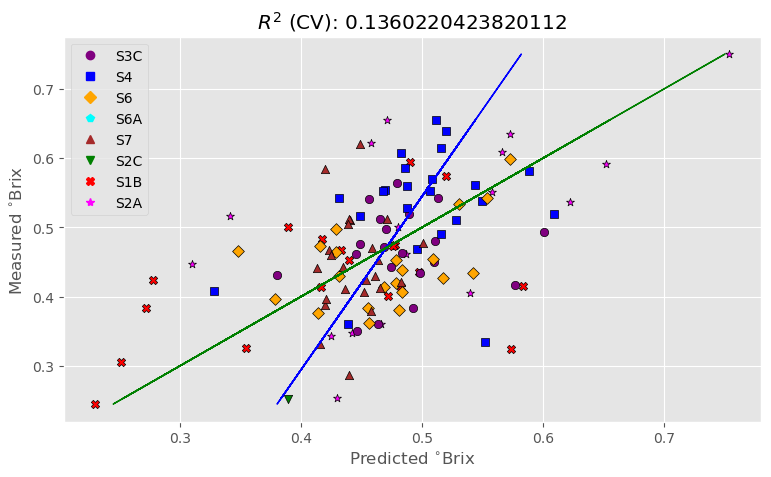

In [17]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [18]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  10
Wavelengths to be kept  25
Optimised MSEP  0.03263328248305848



[0.10752252 0.14130853 0.16047404 0.10934686 0.12149691 0.14057614
 0.150983   0.13430063 0.14208599 0.12289181 0.13189275 0.15028209
 0.1280869  0.12852441 0.1637694  0.13844631 0.17092925 0.12258905
 0.12720985 0.15090514 0.10360575 0.13359612 0.14759758 0.16958462
 0.14421371 0.12632686 0.13825952 0.12750473 0.1382283  0.132517
 0.14348011 0.15914668 0.14055103 0.17168328 0.16486761 0.14002541
 0.1551565  0.14241467 0.15387166 0.15959622 0.16910781 0.14477189
 0.14805481 0.12072159 0.1073527  0.15265722 0.14078436 0.14480546
 0.13584772 0.15887318 0.15398114 0.15597788 0.17070003 0.14105895
 0.14909172 0.13519338 0.1385599  0.13659106 0.16007074 0.1699028
 0.13368793 0.16878202 0.16156701 0.15739136 0.13774637 0.1476133
 0.15970958 0.20893674 0.17268069 0.15561508 0.14510356 0.14919602
 0.15518944 0.19064651 0.17268756 0.2048117  0.1525591  0.16360451
 0.16316227 0.17438206 0.16958938 0.15557781 0.1530371  0.14048121
 0.13762846 0.16373934 0.15155476 0.16889253 0.16792949 0.14920974

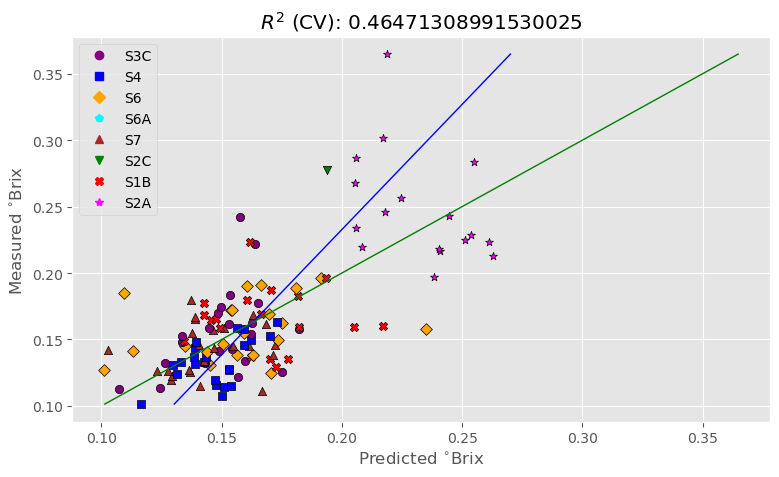

In [19]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [20]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  22
Wavelengths to be kept  30
Optimised MSEP  103.88593093253756



[607.51145388 725.48150203 727.4593991  505.59558158 572.23891629
 638.52574813 542.81462345 740.39340619 542.72002885 611.42137924
 590.99165563 463.46545728 452.13162706 594.27455882 552.31367665
 622.58318996 586.35172836 526.21499037 485.09561946 376.37706665
 637.82145422 490.03221806 348.52279621 250.35524603 362.16951978
 326.25215183 275.92800577 317.93270396 394.89701165 261.91537303
 426.22536766 322.58563299 253.32555149 502.6940203  250.00916764
 206.65421189 559.56078334 547.01065668 445.23775107 493.57165782
 563.66042462 621.13285565 570.52822189 523.90886806 567.22633005
 612.49495711 682.93499654 640.22073725 609.89454339 584.46636379
 543.98200983 576.3882552  552.58203324 600.30667287 604.15017481
 584.76376565 508.51894008 564.4285453  753.59895657 649.77829722
 534.14254924 546.2435142  511.33286563 534.73952126 555.71003057
 526.65545921 579.2252378  666.52200652 496.93786291 591.11868181
 562.81786561 500.5329206  676.09979037 629.46021969 532.42667983
 564.21696

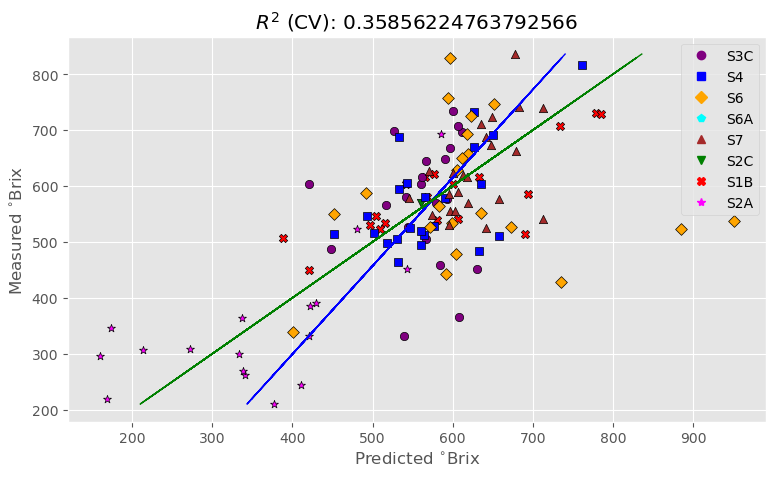

In [21]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [22]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 25)



Optimised number of PLS components:  24
Wavelengths to be kept  34
Optimised MSEP  0.0030523010966788393



[ 9.14803750e-03  7.35202442e-03  4.92271216e-03  1.55729889e-02
  9.52485040e-03  8.48918640e-03  1.01130790e-02  4.80838676e-03
  1.55460043e-02  3.01122097e-03  4.35702746e-03  1.09367393e-02
  1.16176723e-02  9.87941367e-03  1.67434720e-02  2.72275085e-03
  3.89458589e-03  9.87706587e-03  5.11461097e-03  1.52598129e-03
  4.25350965e-03  2.46375735e-03  2.26595039e-03  2.32039571e-03
  1.76152748e-03  1.42771670e-03  5.03831135e-03  4.20389313e-03
  6.23237099e-03  6.79957882e-04  4.00645319e-03  1.42870500e-02
  2.92352026e-03  1.89894727e-04  2.08587265e-03  7.76898402e-03
  8.62673876e-03  2.97669137e-03 -4.17841971e-04  2.85555400e-03
  1.38932526e-03  4.31349803e-03  2.46275828e-03  2.65061772e-03
  4.86113131e-03  4.12128824e-03  3.33405604e-03  3.02330275e-03
  7.00362842e-03  3.17015062e-03  1.55339548e-03  2.95440998e-03
  1.36302226e-03  1.47093028e-03  1.12918149e-03  8.96611362e-04
  4.90532358e-03  3.31990873e-03  2.00003094e-03  1.14381167e-03
  3.50383445e-04  9.52572

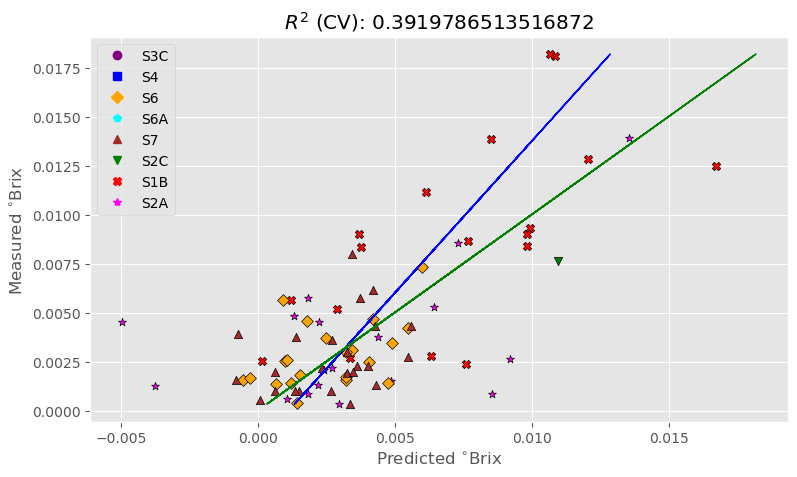

In [23]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [24]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  9
Wavelengths to be kept  45
Optimised MSEP  3.073573099203818



[ 2.78275484  4.74367795  0.46382077  0.71045285  0.04128565  2.7119567
 -1.61003655  2.7787532   5.18786611  3.89026816  1.48103882  2.85045249
  3.06329977  2.94279601  3.17428845  3.69595795  3.36843812  4.44143407
  4.51600723  3.65861247  5.11915021  7.29247428  5.00816275  2.94051538
  4.57258361  2.98041109  6.01509922  3.61785693  8.74656401  3.96077235
  1.86446476  2.49685842  2.89350321  4.95116071  6.01371516  5.33893464
  6.74155124  4.84813883  5.90304223  7.75406284  3.80098421  6.9117809
  6.30557445  5.06854808  6.53396226  4.90051787  5.1854224   6.40247976
  4.89135778  5.92601319  5.60896794  5.75542884  8.68693926  7.77030571
  1.67116877  4.58800692  5.67296155  4.66231623  6.322177    7.11944796
  4.11273177  5.2517943   5.85769453  5.76716981  5.75264736  5.72264675
  4.32696824  5.10641807  8.05368783  5.41565792  8.36209365  6.31466191
  2.60835548  7.95279149  8.39361509  4.66910816  7.80213716  6.00551107
  6.65036747  4.62624738  6.22649935  8.85447826  6.9

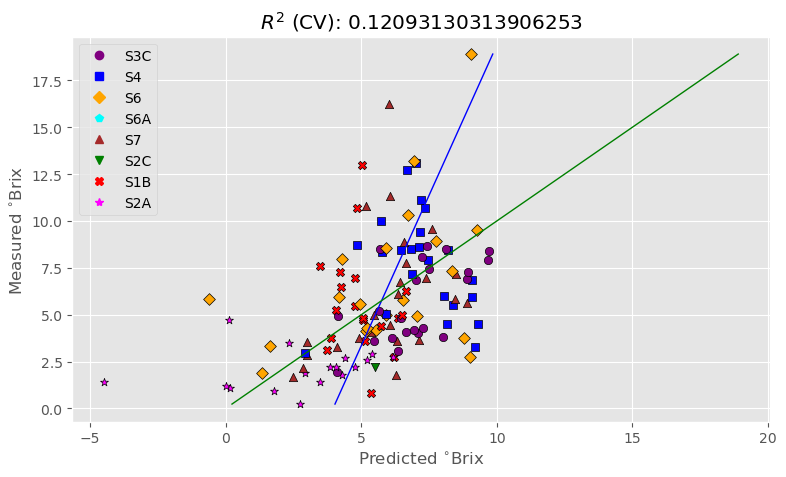

In [25]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [26]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  11
Wavelengths to be kept  73
Optimised MSEP  0.8031647089407798



[-28.98904696 -28.24358314 -28.63853286 -28.22456384 -28.13228951
 -28.51429275 -28.26420803 -28.66405641 -28.61530287 -27.85784429
 -27.47973712 -28.60380789 -27.88989941 -28.11894513 -27.9508875
 -28.15190317 -27.55267033 -28.70097841 -27.72595727 -27.54638582
 -28.38275441 -26.52124846 -26.38184704 -27.7472153  -26.20027761
 -28.394237   -28.57709365 -28.49391219 -28.13907871 -28.57231947
 -28.56396229 -28.56897658 -27.92181642 -27.35114156 -27.9189526
 -27.92429472 -27.80279116 -27.62689573 -28.80686341 -27.75971031
 -27.89755677 -27.05330096 -27.40678053 -26.77860785 -27.58227661
 -27.38553943 -28.12269011 -27.10293082 -27.26064302 -27.49214571
 -28.0098381  -27.81642097 -28.05522859 -27.821929   -28.05459409
 -28.24270166 -27.91103623 -27.52737718 -28.03186684 -27.25608572
 -27.92146128 -27.7816156  -27.39503037 -27.68834276 -29.1578491
 -28.86651086 -28.40215096 -28.18538004 -28.26781044 -28.5163662
 -28.65198559 -28.69263698 -28.2358075  -27.7532957  -28.54456228
 -28.41698487 

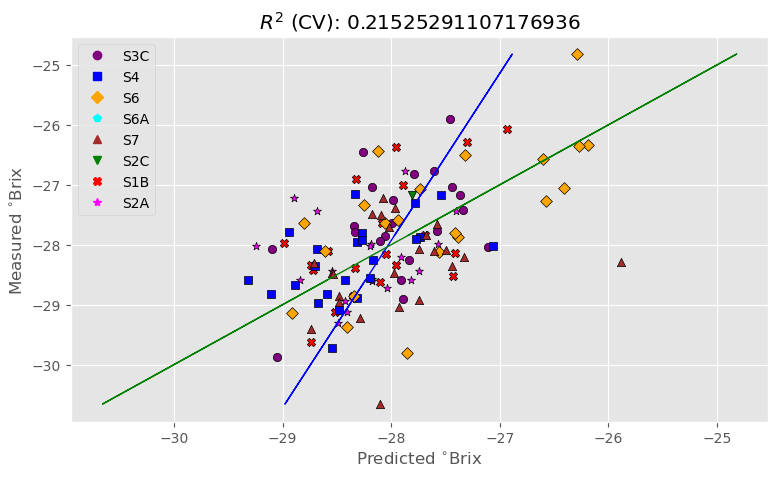

In [27]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  3
Wavelengths to be kept  20
Optimised MSEP  1.7638957305631406

[10.80814875 11.18875732 10.36497869  9.54657862 10.9413084  11.09319591
 10.72861872  9.94137354 10.44664337  7.96718377  9.99723091  7.92702984
 10.00446     8.17069543 10.93676722  8.63862982  9.06187626  8.83405238
  9.24003434  7.85090838  8.15866756 11.05489835  6.81884828  6.86785802
  9.29118039 10.9427235  10.064976   10.6292711  10.72094471 11.46591165
 12.22126325 11.01256909 10.54594755 11.38435314  9.54687011  9.86378928
  9.32669578  9.64769205  9.59312733 11.18287964  9.52353053  9.09573397
  9.2436065   9.19517825 10.20038172 11.55453444  9.47149072 11.55508228
 10.9483012   9.03302972 10.25454893  9.27828765 10.69179086  9.67740699
  9.72947679 10.71199839 10.37160381 10.15545528  9.51824615  9.75662298
 10.14978093 10.31400053 10.13043705  9.3528949  10.33947372 10.27368891
 12.70443578 11.23189416 11.73612289  9.64162482  9.67565404 10.21409894
 10.88023076  9.97939

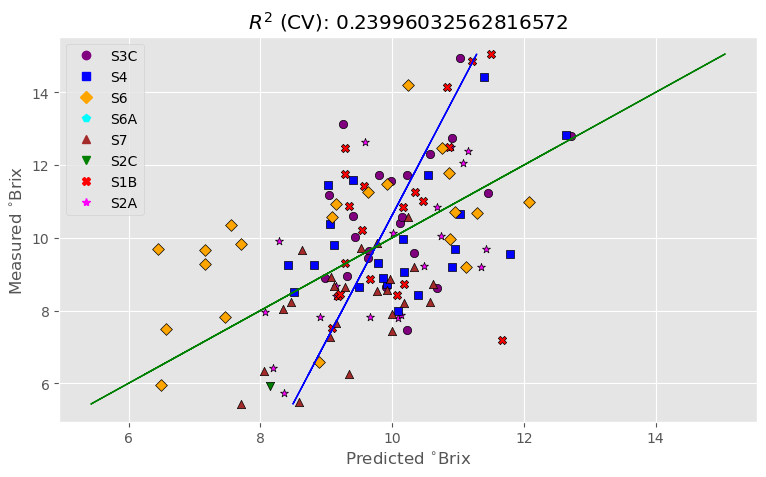

In [28]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  15
Wavelengths to be kept  52
Optimised MSEP  1.2616222338374323

[ 1.83856682  1.45730088  0.52054888  0.62083503  2.81548667  1.04922442
  0.33953358 -2.51556676  0.6562468  -0.54889626 -1.32403049 -0.99189068
 -0.01752489 -5.12860028  0.19678586 -3.05160678 -0.76304445 -0.41359555
 -3.20572283 -0.07468207  2.33770926 -3.09570887  2.69508082  3.57109094
  1.32639838  3.08596152 -0.13318931  1.18849767  2.0084888   0.8259123
  0.59394839  1.07915541  1.83045592  2.23013821  2.72703174  3.08742525
  1.27058566 -1.41497561  0.29390017  1.13848268 -0.06566486  1.17743729
  0.47848525  0.39395059  2.49753022  1.02822457 -0.82422573 -0.90813652
  1.11255331  1.12107181  0.22718955  0.34710081 -0.06068032  0.57688859
 -0.36814633 -0.51409137  0.0617327  -0.24629065  0.75668464  0.11706811
 -0.30711922 -0.0681197   0.40767694  0.31872653  0.06868559 -0.13294407
  0.10493345  0.34469703 -0.5265651   0.45886983 -0.94391351 -1.18039484
 -1.48823373 -0.78368

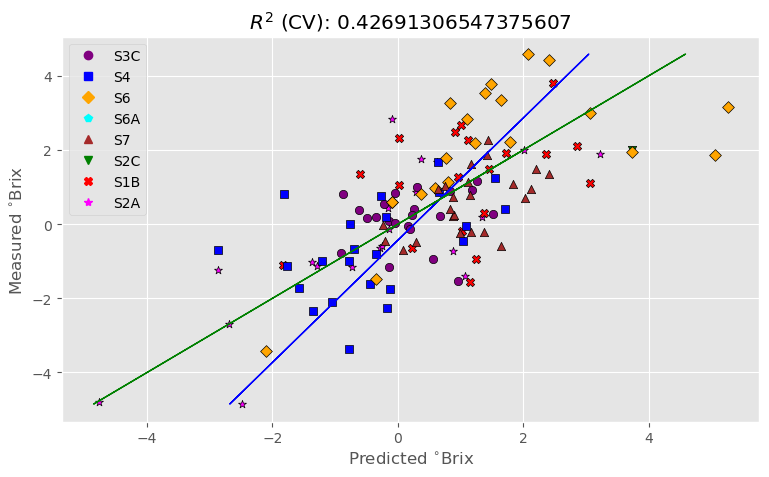

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  20
Wavelengths to be kept  21
Optimised MSEP  9.299551116458247

[34.96803073 44.01477234 42.97483239 42.17242251 51.45971923 46.51839479
 44.36797898 59.00702103 51.17844843 68.22037641 64.24653114 54.42919057
 52.47876951 76.43488814 45.5089816  61.67755147 63.93062451 53.9211501
 59.93591045 54.75152333 69.44594176 47.53236142 54.84802822 60.30563885
 47.69533095 44.80804201 44.89335194 44.33722775 39.96184928 29.45648331
 28.88846697 57.75881396 53.0264573  37.14306316 40.51325047 48.78206356
 58.21470427 42.08179682 52.42707245 32.82181963 56.88624407 58.24051838
 39.36304945 50.02658556 57.26441806 50.40139951 42.7216939  38.46191055
 40.76742199 46.39388012 46.4595925  46.07023883 40.9652353  43.52839719
 46.60417448 42.6867197  45.51668266 43.03427835 47.06707578 42.53740029
 45.30779835 39.59320299 46.38340642 47.23898399 43.67315542 45.48647489
 30.63773219 33.11972537 29.94144467 47.28994827 49.98952955 44.23437481
 43.92905369 50.429707

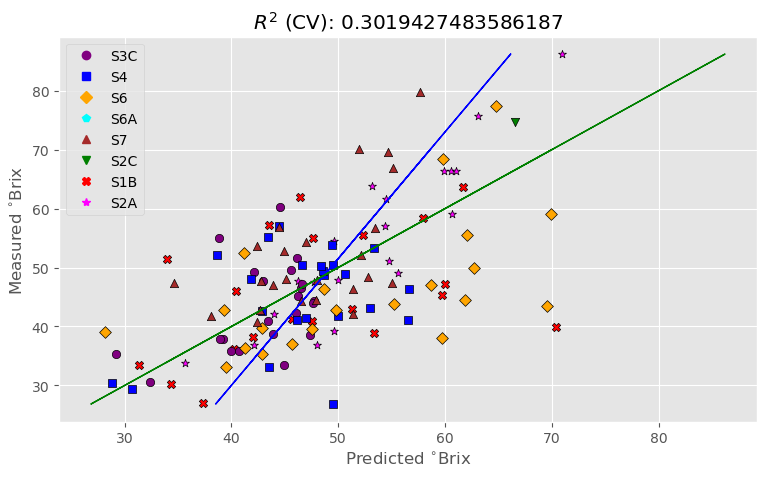

In [30]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  8
Wavelengths to be kept  24
Optimised MSEP  29.832910325534318

[469.88893287 485.3179039  468.1231688  479.4246776  458.51576861
 460.14743724 481.6374624  478.35976557 457.85544189 513.88105402
 493.80282641 482.87427894 481.97217846 492.61735337 474.13202047
 505.97196258 507.14441379 466.90453138 503.62864892 499.36656968
 459.71709436 458.6278283  443.4152339  447.12643126 475.87901792
 458.22551482 439.57708642 426.76556277 442.15029013 427.72652888
 429.16026618 462.67375562 434.89755395 462.41233409 466.24480414
 485.53885771 489.41444456 478.08657232 476.52469497 456.66635459
 471.13806685 470.96884041 477.74498741 472.41308265 469.12257138
 473.31552434 421.73492208 433.49751053 472.79608769 442.33561334
 456.19926535 441.95004479 439.54092807 469.65615542 445.26297842
 454.03064363 468.62997424 443.25449091 455.97299269 456.03662374
 451.79204416 446.05713486 464.81306604 458.04135808 462.60306028
 463.82341984 434.84115461 436.20141648

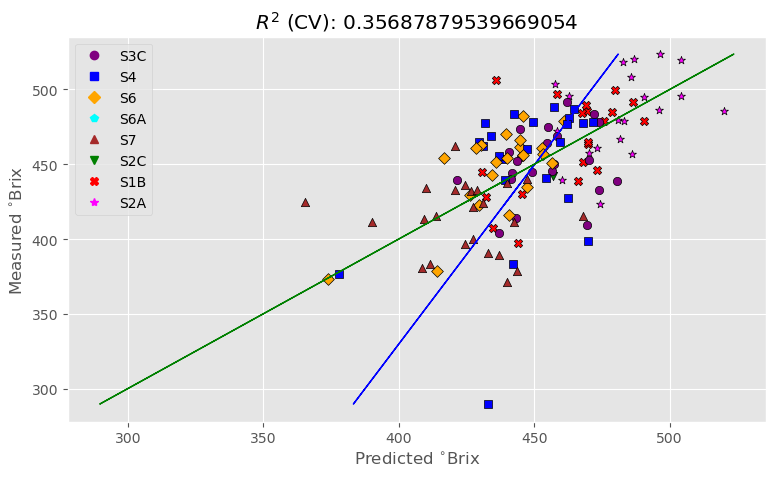

In [31]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
